In [1]:

import jax.numpy as jnp
import cProfile
import sys
sys.path.insert(1,'../scripts/')

import gzip
import pickle
import utils
import loader
import tqdm
%load_ext autoreload
%autoreload 2
import imp
imp.reload(loader)
import setup
import scipy.stats as sts
from matplotlib import pyplot as plt

import numpy as np
import seaborn as sns 
import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

## Functions

In [2]:

def get_corr_time(train_data_folds,test_data_folds,n_folds=100,w=10):

    all_corrs = np.zeros((n_folds,len(_ys[0])-w))*np.nan


    for fold in tqdm.trange(n_folds):
        
        train_fold, test_fold = train_data_folds[fold],test_data_folds[fold]
        ys_time,_ = zip(*train_fold)
        _,cs_time = zip(*test_fold)

        # fitler out sessions with too few neurons or trials
        min_neurons = 100
        min_trials = 20

        valid = [i for i in range(len(ys_time)) if np.array(_ys[i]).shape[-1] >= min_neurons and np.array(_ys[i]).shape[1] >= min_trials]
        ys_time = [ys_time[i] for i in valid]
        cs = [cs_time[i][0] for i in valid]

        S = len(ys_time)


        for t in range(len(ys_time[0])-w):

            # get best min_neurons and current time point +window
            all_sessions = []
            for session in range(S):
                ys_sess = ys_time[session][t:t+w,:].reshape(-1,ys_time[session].shape[-1])
                ys_sess = ys_sess[:,np.argsort(ys_sess.std(0))][:,:min_neurons]
                all_sessions.append(ys_sess)

            try:
                dist_neural = utils.dsd([
                    [all_sessions[i],all_sessions[j]]
                    for i in range(S) 
                    for j in range(S)]
                ).reshape(S,S)


                """dist_cc = np.zeros((S,S))
                for i in range(S):
                    for j in range(S):
                        dist_cc[i,j] = np.mean(np.abs(cs[i]- cs[j]))"""
                
                corr_matrix = np.corrcoef(cs)
                dist_cc = 1 - corr_matrix

                corr = sts.pearsonr(dist_neural[~jnp.eye(dist_neural.shape[0],dtype=bool)],
                        dist_cc[~jnp.eye(dist_cc.shape[0],dtype=bool)])[0]
                
            except Exception as e:

                print(t,fold,"linalg error/nan")
                continue
            
            all_corrs[fold,t]=corr

    return all_corrs

def process_and_correlate_fold(fold, w=10, s=1, r='all'):

    all_corrs = [] # to save the correlations for each time bin

    ys_time, cs_time, regions = fold['ys'], fold['cs_t'], fold['r']

    min_neurons = 100

    S = len(ys_time)

    #mask = np.eye(S, dtype=bool)

    mask = np.triu_indices(S,1)

    # Behavioral distance doesnt change across windows

    corr_matrix = np.corrcoef(cs_time)
    dist_cc = 1 - corr_matrix
    dist_cc = dist_cc[mask]

    ys_time_jax = [jnp.array(ys_time[session]) for session in range(S)]

    # Adding some stride to speed up
    for t in range(0, len(ys_time[0])-w, s):  # Stride of s

        # get best min_neurons and current time point + window
        all_sessions = [ys_time_jax[session][t:t+w,:].reshape(-1, ys_time_jax[session].shape[-1]) for session in range(S)]

        try:
            dist_neural_list = utils.dsd([
                [all_sessions[i],all_sessions[j]]
                for i in range(S) 
                for j in range(i+1,S)]
            )

            # symmetrize the distance matrix
            dist_neural = np.zeros((S,S))
            dist_neural[np.triu_indices(S,1)] = dist_neural_list
            dist_neural = dist_neural[mask]
            
            corr = sts.pearsonr(dist_neural, dist_cc)[0]

        except (np.linalg.LinAlgError, ValueError):
            print(t, " linear algebra error/nan")
            # Can occour when the optimization problem does not converge?
            all_corrs.append(np.nan)
            continue
        
        all_corrs.append(corr)

    return all_corrs


## Loading

In [6]:
with open("prep_data/folds_index_stim.pkl","rb") as f:
    index = pickle.load(f)

with gzip.open(f"{index['files'][0]}", "rb") as g:
    fold = pickle.load(g)

In [50]:
print(len(fold['ys'])) # number of sessions
print(len(fold['ys'][0])) # number of time points
print(fold['ys'][0][0].shape) # shape of each time point (cond, neurons)

32
150
(9, 367)


In [ ]:
yw=fold['ys'][0][0:10]
yw.reshape(-1,yw.shape[-1]).shape

In [11]:
with open("prep_data/all/folds_index_response.pkl","rb") as f:
    index = pickle.load(f)

fold_path = index['files'][0]
with gzip.open(f"{fold_path}", "rb") as g:
    fold = pickle.load(g)
cProfile.run("process_and_correlate_fold(fold, w=15, s=2)")

         2807673 function calls (2789193 primitive calls) in 67.184 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.028    0.028   67.186   67.186 2020683841.py:60(process_and_correlate_fold)
        1    0.000    0.000    0.077    0.077 2020683841.py:80(<listcomp>)
        6    0.002    0.000    0.136    0.023 2020683841.py:86(<listcomp>)
        6    0.003    0.000    0.003    0.001 2020683841.py:89(<listcomp>)
    19158    0.057    0.000    0.073    0.000 <frozen importlib._bootstrap>:1053(_handle_fromlist)
        6    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:404(parent)
    18480    0.027    0.000    0.051    0.000 <string>:1(<lambda>)
        1    0.001    0.001   67.187   67.187 <string>:1(<module>)
        6    0.000    0.000    0.000    0.000 <string>:1(__new__)
       36    0.000    0.000    0.000    0.000 <string>:13(__setattr__)
        6    0.000    0.000    0.000    0.000 <

In [33]:
with open("prep_data/all/folds_index_response.pkl","rb") as f:
    index = pickle.load(f)

fold_path = index['files'][0]
with gzip.open(f"{fold_path}", "rb") as g:
    fold = pickle.load(g)
cProfile.run("process_and_correlate_fold(fold, w=15, s=2)")

         2324040 function calls (2305560 primitive calls) in 100.431 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        6    0.000    0.000    0.001    0.000 3770509694.py:110(<listcomp>)
        6    0.002    0.000    0.003    0.000 3770509694.py:113(<listcomp>)
        1    0.029    0.029  100.468  100.468 3770509694.py:86(process_and_correlate_fold)
    18486    0.078    0.000    0.098    0.000 <frozen importlib._bootstrap>:1053(_handle_fromlist)
        6    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:404(parent)
       50    0.000    0.000    0.000    0.000 <string>:1(<lambda>)
        1    0.000    0.000  100.468  100.468 <string>:1(<module>)
        6    0.000    0.000    0.000    0.000 <string>:1(__new__)
       36    0.000    0.000    0.000    0.000 <string>:13(__setattr__)
        6    0.000    0.000    0.000    0.000 <string>:4(__init__)
     9240    0.066    0.000    0.116    0.000 __init

In [3]:
# load data - response aligned

with open("prep_data/all/folds_index_response.pkl","rb") as f:
    index = pickle.load(f)

all_corrs_resp = []
for fold_path in tqdm.tqdm(index['files'][:2]):
    with gzip.open(f"{fold_path}", "rb") as g:
        fold = pickle.load(g)

        all_corrs = process_and_correlate_fold(fold, w=15, s=2)
        all_corrs_resp.append(all_corrs)

all_corrs_resp = np.array(all_corrs_resp)


  0%|          | 0/2 [00:00<?, ?it/s]

/home/blopes/.pyenv/versions/3.10.15/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
2026-05-13 10:32:20,317	INFO worker.py:2013 -- Started a local Ray instance.
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(_deterministic_metrics_pair pid=275418) ERROR:2026-05-13 10:32:23,111:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
(_deterministic_metrics_pair pid=275418) Traceback (most recent call last):
(_deterministic_metrics_pair pid=

In [4]:
# load data - stimulus aligned

with open("prep_data/all/folds_index_stim.pkl","rb") as f:
    index = pickle.load(f)

all_corrs_stim = []
i=0
for fold_path in tqdm.tqdm(index['files'][:2]):
    #if i==2: break
    #i+=1

    with gzip.open(f"{fold_path}", "rb") as g:
        fold = pickle.load(g)

        all_corrs = process_and_correlate_fold(fold, w=15, s=2)
        all_corrs_stim.append(all_corrs)

#all_corrs_stim = get_corr_time(train_data_folds,test_data_folds,n_folds=25)
all_corrs_stim = np.array(all_corrs_stim)

    

100%|██████████| 2/2 [22:35<00:00, 677.97s/it]


In [41]:
with(open("prep_data/25_avg_folds_stim_aligned.pkl","rb")) as f:
    import pickle
    params,_ys,train_data_folds,test_data_folds = pickle.load(f)

all_corrs_stim = get_corr_time(train_data_folds,test_data_folds,n_folds=25)



  4%|▍         | 1/25 [01:08<27:31, 68.83s/it]

7 1 linalg error/nan
23 1 linalg error/nan
27 1 linalg error/nan
61 1 linalg error/nan
72 1 linalg error/nan


  8%|▊         | 2/25 [02:20<27:03, 70.59s/it]

38 2 linalg error/nan
79 2 linalg error/nan


 12%|█▏        | 3/25 [03:31<26:00, 70.93s/it]

...

 92%|█████████▏| 23/25 [27:17<02:22, 71.20s/it]

59 23 linalg error/nan
132 23 linalg error/nan


 96%|█████████▌| 24/25 [28:28<01:10, 71.00s/it]

71 24 linalg error/nan


100%|██████████| 25/25 [29:39<00:00, 71.17s/it]


In [ ]:
print(len(ys)) # number of sessions/animals - it is taking just 2?
print(len(ys[0]))
print(len(ys[1]))
print(ys[0][1].shape)

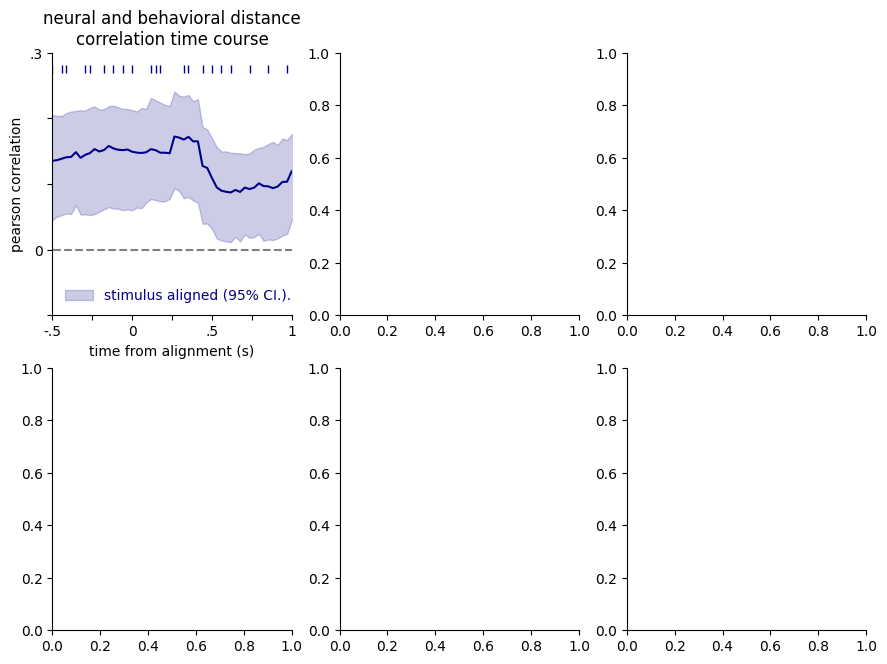

In [5]:
from matplotlib import pyplot as plt

all_corrs = all_corrs_resp

sig_resp = (1-np.nanmean(all_corrs>0,0))*2 <0.05

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))
axes = axes.flatten()

x_time = np.linspace(-1,1,len(all_corrs[0]))
w=10
x_time += np.diff(x_time)[0]*w

axes[0].plot(x_time,np.nanmean(all_corrs,0),color="darkblue")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs.T],[np.nanpercentile(a,97.5) for a in all_corrs.T],color='darkblue',alpha=0.2,label='stimulus aligned (95% CI.).')

axes[0].plot(x_time[sig_resp],np.ones_like(x_time[sig_resp])*0.275,'|',color='darkblue')

axes[0].plot(x_time,np.zeros_like(x_time),'--',color='k',alpha=0.5)
axes[0].set_xlabel('time from alignment (s)')
axes[0].set_ylabel('pearson correlation')
axes[0].set_title('neural and behavioral distance\ncorrelation time course')
axes[0].legend()
axes[0].set_ylim(-0.1,0.3)
axes[0].set_xlim(-0.5,1)
axes[0].set_xlim(-0.5,1)
axes[0].set_ylim(-0.1,0.3)
axes[0].set_yticks([-0.1,0,0.1,0.2,0.3],['',0,'','','.3'])
axes[0].set_xticks([-0.5,-0.25,0,0.25,0.5,0.75,1],['-.5','','0','','.5','','1'])
axes[0].legend(frameon=False)
# change font color of legend
leg = axes[0].get_legend()
ltext  = leg.get_texts()

#plt.setp(ltext[1], color='darkred')
plt.setp(ltext[0], color='darkblue')
sns.despine()
#fig.tight_layout()


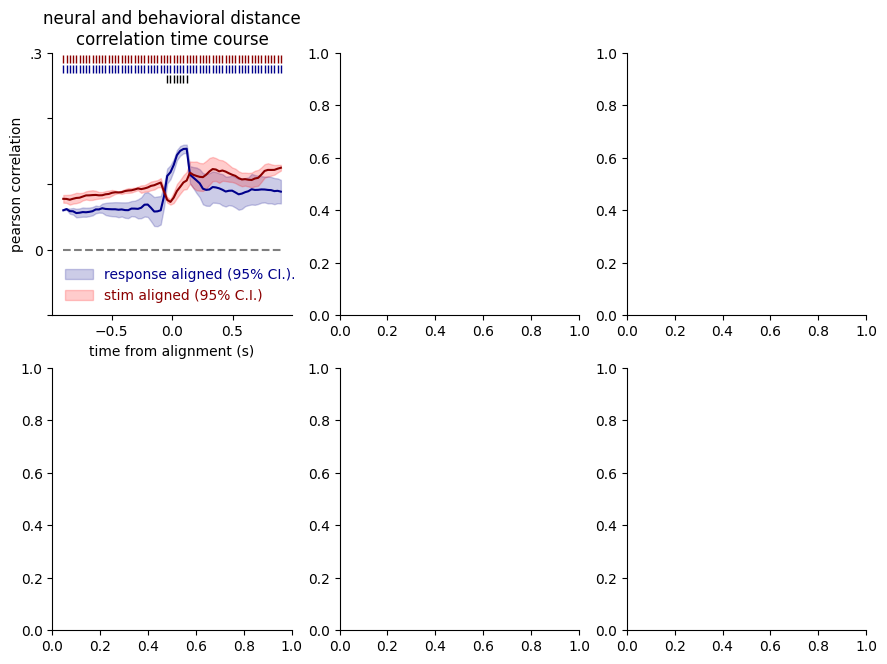

In [24]:
from matplotlib import pyplot as plt

sig_stim = (1-np.nanmean(all_corrs_stim>0,0))*2 <0.05
sig_resp = (1-np.nanmean(all_corrs_resp>0,0))*2 <0.05
sig_stim_resp = (1-np.nanmean(all_corrs_stim<np.nanmean(all_corrs_resp,0),0))*2 <0.05

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))
axes = axes.flatten()

#First approach
"""x_time = np.linspace(-1,1,len(all_corrs_stim[0]))
w=15
x_time += np.diff(x_time)[0]*w"""

## Second approach
w,s = 15,2
idx = np.array(list(range(0,150-w,s)))
x_time = np.linspace(-1,1,150)
diff = np.diff(x_time)[0]*w/2
x_time = x_time[idx]+diff

axes[0].plot(x_time,np.nanmean(all_corrs_resp,0),color="darkblue")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs_resp.T],[np.nanpercentile(a,97.5) for a in all_corrs_resp.T],color='darkblue',alpha=0.2,label='response aligned (95% CI.).')


axes[0].plot(x_time,np.nanmean(all_corrs_stim,0),color="darkred")
axes[0].fill_between(x_time,[np.nanpercentile(a,2.5) for a in all_corrs_stim.T],[np.nanpercentile(a,97.5) for a in all_corrs_stim.T],color='r',alpha=0.2,label='stim aligned (95% C.I.)')

axes[0].plot(x_time[sig_stim],np.ones_like(x_time[sig_stim])*0.29,'|',color='darkred')
axes[0].plot(x_time[sig_resp],np.ones_like(x_time[sig_resp])*0.275,'|',color='darkblue')
axes[0].plot(x_time[sig_stim_resp],np.ones_like(x_time[sig_stim_resp])*0.26,'|',color='k')

axes[0].plot(x_time,np.zeros_like(x_time),'--',color='k',alpha=0.5)
axes[0].set_xlabel('time from alignment (s)')
axes[0].set_ylabel('pearson correlation')
axes[0].set_title('neural and behavioral distance\ncorrelation time course')
axes[0].legend()
#axes[0].set_xlim(-1,1)
axes[0].set_ylim(-0.1,0.3)
axes[0].set_yticks([-0.1,0,0.1,0.2,0.3],['',0,'','','.3'])
#axes[0].set_xticks([-0.5,-0.25,0,0.25,0.5,0.75,1],['-.5','','0','','.5','','1'])
axes[0].legend(frameon=False)
# change font color of legend
leg = axes[0].get_legend()
ltext  = leg.get_texts()

plt.setp(ltext[1], color='darkred')
plt.setp(ltext[0], color='darkblue')
sns.despine()
#fig.tight_layout()

plt.savefig('../results/neural_behavioral_correlation_time_DG.svg',dpi=300)


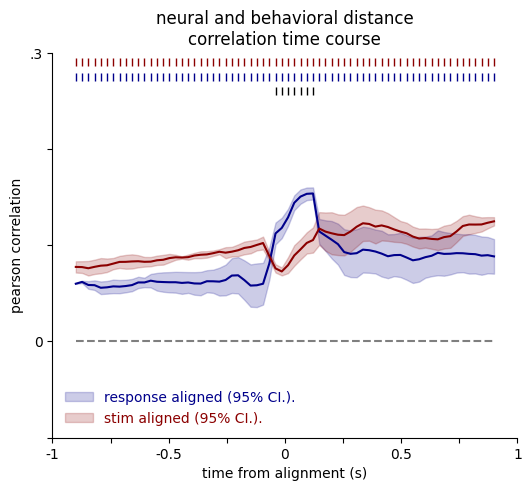

In [33]:
sys.path.insert(1,'../scripts/')

from utils import plot_time_corrs
all_corrs = {'response': all_corrs_resp, 'stim': all_corrs_stim}
plot_time_corrs(all_corrs, w=15, s=2)